In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

## Load participant data and meta files 

In [3]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [4]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

In [5]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v02')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v02/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    manifest_file = manifest_dict[part_name]
    part_df = util_process.get_part_df(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add transcripts for scoring 
results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]


cols_to_score = ['response', 'target_word', 'distractor_1_word', 'distractor_2_word', 'target_transcripts', 'dist_1_transcripts', 'dist_2_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_1_word, distractor_2_word, target_transcripts, dist_1_transcripts, dist_2_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_1_transcripts or response in dist_2_transcripts or response in [distractor_1_word, distractor_2_word]))

results_df['correct'] = correct
results_df['confusions'] = confusions

In [6]:
results_df.participant.unique()

array(['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'participant_006',
       'participant_007', 'participant_008', 'participant_009',
       'participant_010', 'participant_011', 'participant_012',
       'participant_013'], dtype=object)

## add transcripts for scoring 


In [7]:
results_df['distractor_elev_delta'] = (results_df['distractor_elev'] - results_df['target_elev']).abs()

In [8]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim',
                                   'distractor_elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]



In [9]:
part_perf_avg = grouped_part_results.groupby('participant').correct_mean.mean()

cutoff = 0.4
good_parts = part_perf_avg[part_perf_avg > cutoff].index

good_part_results = grouped_part_results[grouped_part_results.participant.isin(good_parts)]

### Threshold estimate proceedure

Will be plotting grand average thresholds:
1) average participant data per condition
2) fit thresholds to averaged data
3) bootstrap over participants for error bars 

Actual implementation will use pandas and seaborn to plot average, just need to save individual bootstraps



In [10]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 

# avg threshold estimates 
# avg_thresholds = []
# avg_df = grouped_part_results.groupby(['distractor_azim', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
# for (dist_azim, dist_elev), group in avg_df.groupby(['distractor_azim', 'distractor_elev_delta', ]):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)
#     avg_thresholds.append({'dist_azim':dist_azim, 'dist_elev_delta':dist_elev,  'threshold':thresh})
# avg_thresh_df = pd.DataFrame(avg_thresholds)
# avg_thresh_df

thresholds = []
for (participant, target_azim, target_elev, dist_azim, dist_elev, n_dist), group in grouped_part_results.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim', 'distractor_elev_delta', 'n_distractors']): #, 'gender_cond']):
    try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)
    except Exception as e:
        print(e)
        print(f"Threshold estimation failed for {participant}, {target_azim}, {target_elev}, {dist_azim}, {dist_elev}, {n_dist}")
        thresh = np.nan
    # if np.isnan(thresh):
		# print(f"Threshold is nan for {participant}, {target_azim}, {target_elev}, {dist_azim}, {dist_elev}, {n_dist}")

    thresholds.append({'participant':participant, 'target_azim':target_azim, 'target_elev':target_elev, 
                    'dist_azim':dist_azim, 'distractor_elev_delta':dist_elev, 'n_distractors':n_dist,'threshold':thresh}) #  'gender_cond':gend_cond,

human_thresh_df = pd.DataFrame(thresholds)


In [11]:
# human_thresh_df

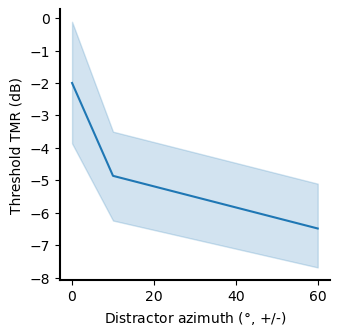

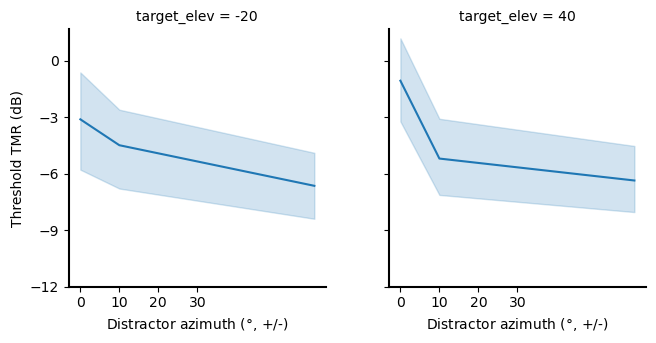

In [15]:
to_plot = human_thresh_df[(human_thresh_df.n_distractors==2) & (human_thresh_df.distractor_elev_delta == 0 )].copy()

## Clip for plotting 
# human_thresh_df.loc[human_thresh_df['threshold'] < -10, 'threshold'] = -10
# human_thresh_df.loc[human_thresh_df['threshold'] > 0, 'threshold'] = 0
to_plot['distractor_azim'] = to_plot.dist_azim.abs()

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                # error_ba
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
# g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
        

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                col='target_elev',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

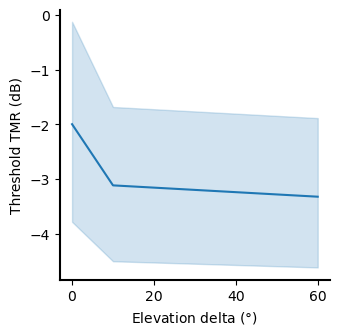

In [16]:
to_plot = human_thresh_df[(human_thresh_df.n_distractors==2) & (human_thresh_df.dist_azim == 0 )].copy()
# to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['dist_elev']).abs()

g = sns.relplot(data=to_plot, x='distractor_elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Elevation delta ($\degree$)", "Threshold TMR (dB)")
# g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

## Load model data and meta files

In [17]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [18]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [19]:
manifest_df  = pd.DataFrame(manifest.values())
# manifest_df

In [20]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [21]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment/").glob("*/*room*.pkl"))

output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment_v02/").glob("*/*.pkl"))
# output_paths.extend(list(Path(f"binaural_eval/simulate_2024_human_array_experiment_white_noise_dist/").glob("*/*.pkl")))
# output_paths.append(list(Path(f"binaural_eval/texture_srm_experiment/").glob("*/*.pkl")))

stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

## Get anechoic room for comparison 
# output_paths += list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*eval*room0000.pkl"))
# anech_stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')
 
word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    # if not 'mitb46' in path.stem:
    #     continue 
    if 'white_noise' in path.as_posix():
        continue
    if 'texture' in path.as_posix():
        continue

    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    if 'white_noise' in path.as_posix():
        df['distractor_type'] = 'white_noise'
    elif 'texture' in path.as_posix():
        df['distractor_type'] = 'texture'
    else:
        df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [22]:
re.search('SNR_(.*?)_room', path.stem).group(0)

'SNR_speech_distractor_min_reverb_room'

In [23]:
results.room_type.unique()

array(['speech_distractor_min_reverb'], dtype=object)

In [24]:
results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [25]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [26]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set', 'distractor_type',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [27]:
grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()

In [28]:
grouped_part_results.distractor_azim.value_counts()

0     234
10     78
60     78
Name: distractor_azim, dtype: int64

In [29]:
grouped_part_results

,participant,target_azim,target_elev,distractor_azim,distractor_elev_delta,snr,n_distractors,correct_mean,correct_sem,confusions_mean,confusions_sem,confusions_count
0,participant_001,0,40,0,0,-9,2,0.1875,0.100778,0.1250,0.085391,16
1,participant_001,0,40,0,0,-6,2,0.2500,0.111803,0.1875,0.100778,16
2,participant_001,0,40,0,0,-3,2,0.3125,0.119678,0.2500,0.111803,16
3,participant_001,0,40,0,0,0,2,0.2500,0.111803,0.0625,0.062500,16
4,participant_001,0,40,0,0,3,2,0.7500,0.111803,0.0000,0.000000,16
...,...,...,...,...,...,...,...,...,...,...,...,...
385,participant_013,0,40,60,0,-6,2,0.9375,0.062500,0.0000,0.000000,16
386,participant_013,0,40,60,0,-3,2,0.9375,0.062500,0.0000,0.000000,16
387,participant_013,0,40,60,0,0,2,1.0000,0.000000,0.0000,0.000000,16
388,participant_013,0,40,60,0,3,2,1.0000,0.000000,0.0000,0.000000,16


In [30]:
# put humans and model in same dataframe. Change correct to accuracy in column names 
grouped_model_results.rename(columns={'accuracy_mean':'correct_mean', 'accuracy_sem':'correct_sem'}, inplace=True)
grouped_model_results['group'] = 'Model'
N = grouped_part_results.participant.nunique()
grouped_part_results['group'] = f'Humans (N={N})'
merged_results = pd.concat([grouped_model_results, grouped_part_results], ignore_index=True, axis=0)

# N = good_part_results.participant.nunique()
# good_part_results['group'] = f'Humans (N={N})'
# merged_results = pd.concat([grouped_model_results, good_part_results], ignore_index=True, axis=0)



# N = grouped_part_results.participant.nunique()
# grouped_part_results['group'] = f'Humans (N={N})'


# merged_good_parts = merged_results[merged_results.participant.isin(good_parts)]

In [31]:
merged_results.group.unique()

array(['Model', 'Humans (N=13)'], dtype=object)

Text(0.5, 1.05, 'Azimuth performance')

<Figure size 640x480 with 0 Axes>

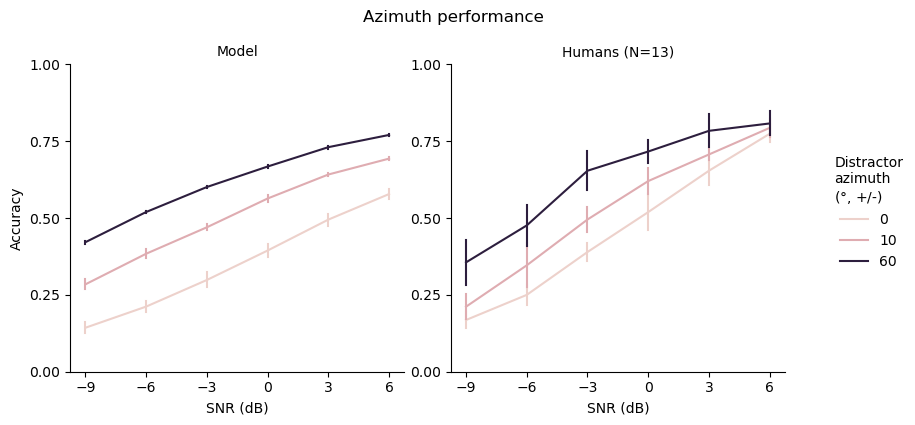

In [32]:


## First, get grand average. Then bootstrap for error 
# sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        & (merged_results.distractor_elev_delta.eq(0 ))
                         & (merged_results.distractor_azim.abs().isin([0,10, 60])) 
                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='group', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
plt.suptitle(f'Azimuth performance', y=1.05)

# plot azim thresholds
# sns.set_style('white')
# fig, axs = plt.subplots(1,2, figsize=(9, 4))
# g = sns.lineplot(data=azim_thresh_df, x='azim', y='threshold', hue='dist_type', style='room', marker='o', ax=axs[0],  legend=False)
# # axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

# axs[0].set_xlabel('Distractor azimuth ($\degree$, +/-)')
# axs[0].set_ylabel("Threshold (dB SNR)")
# axs[0].set_ylim(-15,5)
# axs[0].set_xticks(np.arange(0, 31, 10))

# # get srm per model
# for model in azim_thresh_df.model.unique():
#     for dist_type in azim_thresh_df.dist_type.unique():
#         for room_type in azim_thresh_df.room.unique():
#             ixs = (azim_thresh_df.model == model) & (azim_thresh_df.dist_type == dist_type) & (azim_thresh_df.room == room_type)
#             model_data = azim_thresh_df[ixs]
#             azim_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# # sns.set_style('white')
# g = sns.lineplot(data=azim_thresh_df, x='azim', y='srm', hue='dist_type', style='room', marker='o', ax=axs[1], legend=True)
# # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
# axs[1].set_xlabel('Distractor azimuth ($\degree$, +/-)')
# axs[1].set_ylabel("Spatial release (dB SNR)")
# axs[1].set_ylim(-15,5)
# axs[1].set_xticks(np.arange(0, 31, 10))

# # adjust w space 
# plt.subplots_adjust(wspace=0.6)
# # adjust legend 
# handles, labels = axs[1].get_legend_handles_labels()
# axs[1].legend(handles=handles, labels=labels, title='Distractor type', loc='center right', fontsize=12, title_fontsize=12, bbox_to_anchor=(2.1, 0.5))



In [33]:
# merged_results[merged_results.distractor_azim == 0].distractor_elev_delta.unique()

<Figure size 640x480 with 0 Axes>

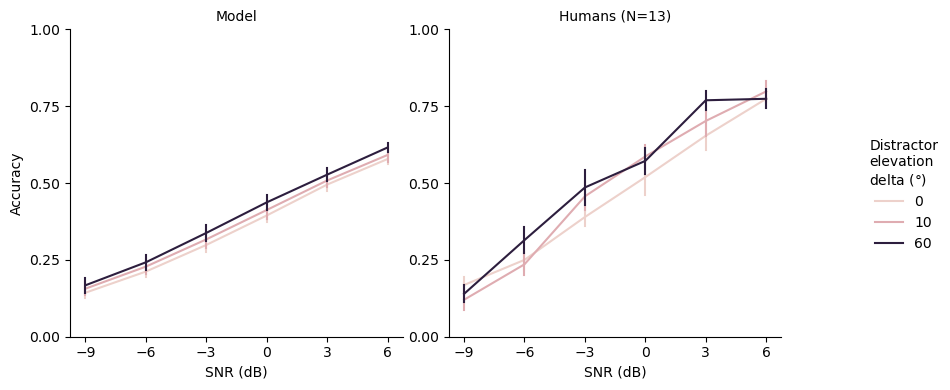

In [34]:
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                        &	(merged_results.distractor_azim == 0) 
                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='group', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)